# Skylark Drones — GCP Pose Estimation Pipeline
**EfficientNet-B2 dual-head: keypoint regression + shape classification**

In [1]:
# ── 1. Install dependencies ────────────────────────────────────────────────
!pip install -q timm albumentations scikit-learn tqdm


In [3]:
# ── 2. Mount Google Drive (if using Drive for dataset / weights) ──────────
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# ── 3. Clone / upload the pipeline scripts ────────────────────────────────
# Option A: clone your GitHub repo
# !git clone https://github.com/YOUR_USER/skylark-gcp.git && cd skylark-gcp

# Option B: upload the files from your local machine
# from google.colab import files
# files.upload()   # upload dataset.py, model.py, train.py, inference.py

import os
os.chdir('/content')   # adjust if needed


In [26]:
# ── 4. Set paths ──────────────────────────────────────────────────────────
TRAIN_ROOT = '/content/drive/MyDrive/train_dataset'   # ← adjust
JSON_PATH  = f'{TRAIN_ROOT}/gcp_marks.json'
TEST_ROOT  = '/content/drive/MyDrive/test_dataset'    # ← adjust
OUTPUT_DIR = '/content/runs/exp1'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify GPU
import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')


Tesla T4


In [6]:
!git clone https://github.com/SrishtikSekar/SkylarkDrones-ComputerVision.git

Cloning into 'SkylarkDrones-ComputerVision'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 40 (delta 17), reused 33 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 28.79 KiB | 9.59 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [7]:
!git pull origin main

fatal: not a git repository (or any of the parent directories): .git


Total annotated images : 1000
Missing shape label    : 4
Shape distribution     : {'Cross': 177, 'Square': 328, 'L-Shape': 491}

X  → min=67.0  max=3937.1  mean=1973.7
Y  → min=35.0  max=2914.1  mean=1438.4

File existence check (first 200): found=97, missing=103
Image W → 4096 – 4096   H → 2730 – 3068
Most common sizes: [((4096, 3068), 59), ((4096, 2730), 38)]

EDA plot saved → eda_outputs/eda_summary.png
Sample crops saved → eda_outputs/sample_crops.png


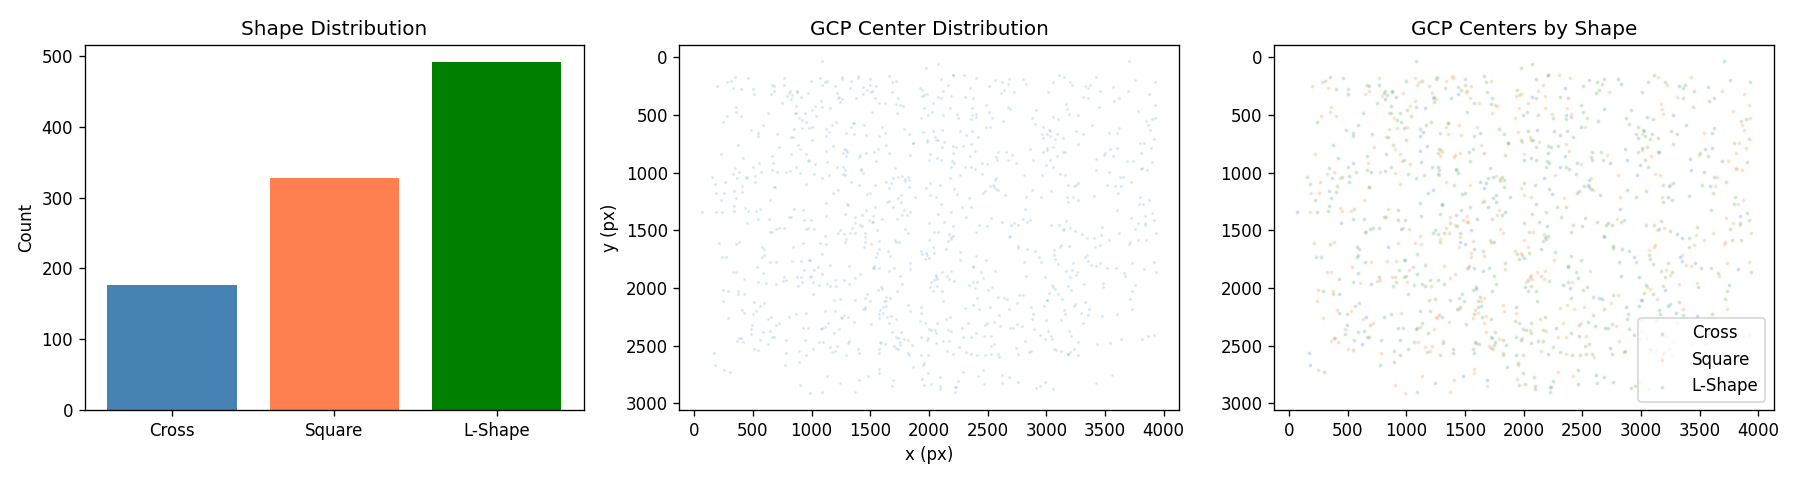

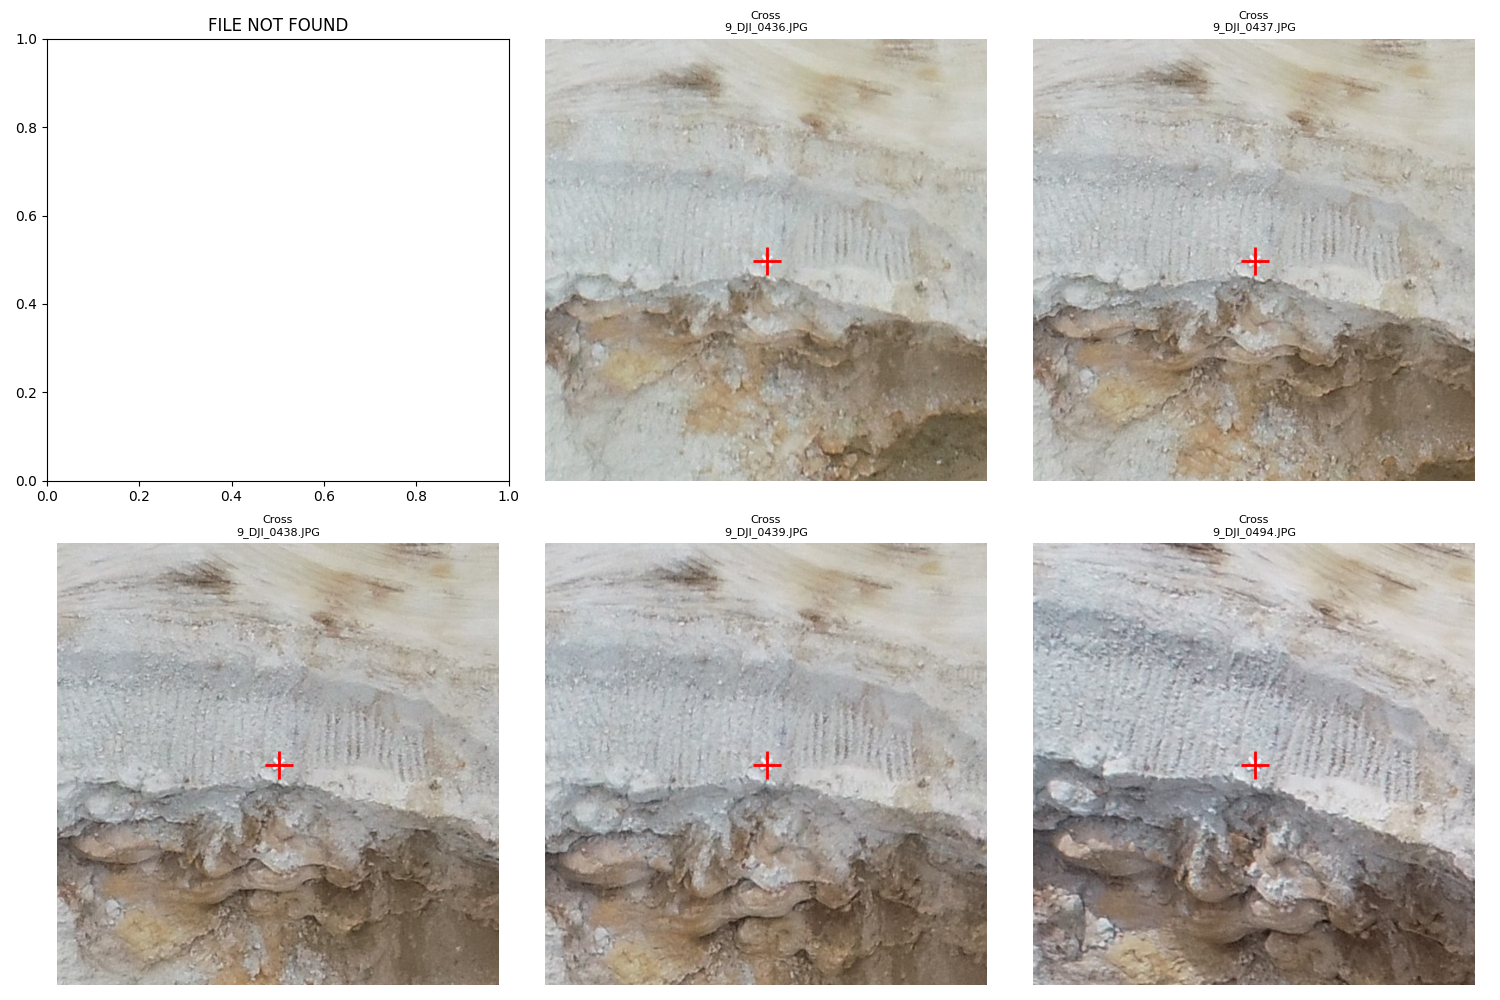

In [8]:
# ── 5. EDA ────────────────────────────────────────────────────────────────
!python /content/SkylarkDrones-ComputerVision/eda.py \
  --data_root {TRAIN_ROOT} \
  --json      {JSON_PATH} \
  --output_dir eda_outputs

from IPython.display import Image as IPImage, display
display(IPImage('eda_outputs/eda_summary.png'))
display(IPImage('eda_outputs/sample_crops.png'))


In [9]:
%cd /content/SkylarkDrones-ComputerVision

/content/SkylarkDrones-ComputerVision


In [10]:
# ── 6. Quick architecture sanity check ───────────────────────────────────
from model import GCPNet
import torch

model = GCPNet('efficientnet_b2', pretrained=False)
x = torch.randn(2, 3, 512, 512)
coords, logits = model(x)
print(f'coords: {coords.shape}  logits: {logits.shape}')
print(f'Params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')


coords: torch.Size([2, 2])  logits: torch.Size([2, 3])
Params: 8.6M


In [11]:
# ── 7. Train ──────────────────────────────────────────────────────────────
# Recommended settings for T4:
#   batch_size=16 with efficientnet_b2 fits comfortably
#   Increase to 24 with efficientnet_b0 or MobileNetV3

!python /content/SkylarkDrones-ComputerVision/train.py \
  --data_root   {TRAIN_ROOT} \
  --json        {JSON_PATH} \
  --output_dir  {OUTPUT_DIR} \
  --backbone    efficientnet_b2 \
  --epochs      15 \
  --batch_size  16 \
  --lr          3e-4 \
  --val_frac    0.15 \
  --num_workers 2 \
  --fp16


Streaming output truncated to the last 5000 lines.
[ WARN:0@1093.965] global loadsave.cpp:278 findDecoder imread_('/content/drive/MyDrive/train_dataset/231129_CTD/231129_CTD_GDA94/11/DJI_20231129142308_0148.JPG'): can't open/read file: check file path/integrity
[ WARN:0@1093.966] global loadsave.cpp:278 findDecoder imread_('/content/drive/MyDrive/train_dataset/scout_966/a7ee1866bbb652c2d0b92546/GCP67/DJI_20260211112005_0576_D.JPG'): can't open/read file: check file path/integrity
[ WARN:0@1094.575] global loadsave.cpp:278 findDecoder imread_('/content/drive/MyDrive/train_dataset/Vedanta GOA Bicholim/MCDR 2024/GCP19/15_3_DJI_0375.JPG'): can't open/read file: check file path/integrity
[ WARN:0@1094.576] global loadsave.cpp:278 findDecoder imread_('/content/drive/MyDrive/train_dataset/Egypt-New city/Survey 1/14G66/DJI_20241107100942_0083.JPG'): can't open/read file: check file path/integrity
[ WARN:0@1094.576] global loadsave.cpp:278 findDecoder imread_('/content/drive/MyDrive/train_datas

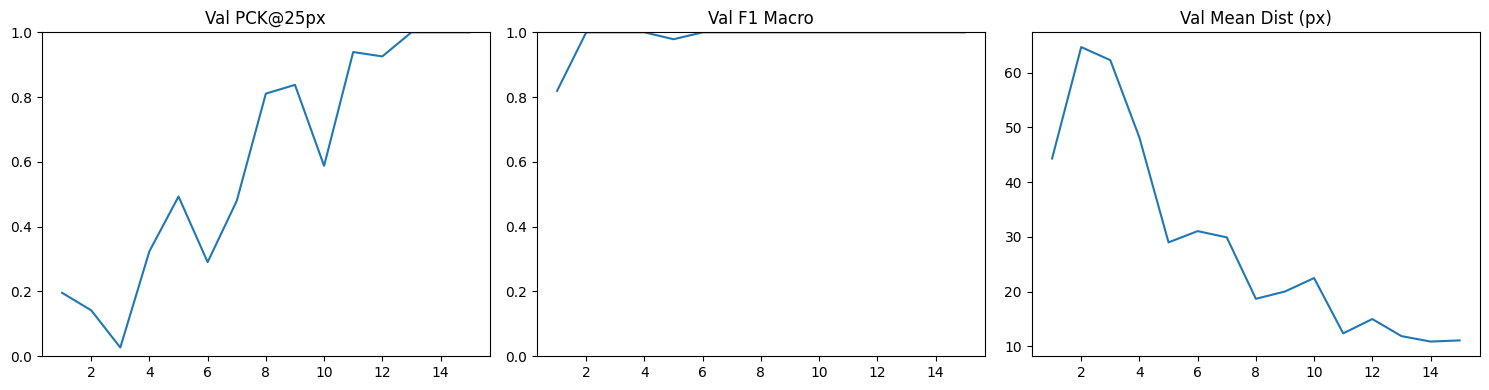

In [12]:
# ── 8. Plot training history ──────────────────────────────────────────────
import json, matplotlib.pyplot as plt

with open(f'{OUTPUT_DIR}/history.json') as f:
    hist = json.load(f)

epochs   = [h['epoch']            for h in hist]
pck25    = [h['val_PCK@25px']     for h in hist]
f1       = [h['val_f1_macro']     for h in hist]
dist     = [h['val_mean_dist_px'] for h in hist]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, pck25);  axes[0].set_title('Val PCK@25px'); axes[0].set_ylim(0,1)
axes[1].plot(epochs, f1);     axes[1].set_title('Val F1 Macro'); axes[1].set_ylim(0,1)
axes[2].plot(epochs, dist);   axes[2].set_title('Val Mean Dist (px)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=120)
plt.show()


In [24]:
!git pull origin main


remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 496 bytes | 496.00 KiB/s, done.
From https://github.com/SrishtikSekar/SkylarkDrones-ComputerVision
 * branch            main       -> FETCH_HEAD
   5c814b9..ff59801  main       -> origin/main
Updating 5c814b9..ff59801
Fast-forward
 inference.py | 20 +++++++++++++++-----
 1 file changed, 15 insertions(+), 5 deletions(-)


In [27]:
# # ── 9. Generate predictions.json on test set ──────────────────────────────
# !python inference.py \
#   --test_root  {TEST_ROOT} \
#   --weights    {OUTPUT_DIR}/best_model.pth \
#   --output     predictions.json \
#   --backbone   efficientnet_b2 \
#   --stride     300 \
#   --batch_size 8

!python inference.py \
  --test_root {TEST_ROOT} \
  --weights /content/runs/exp1/best_model.pth\
  --jpg_paths /content/drive/MyDrive/test_dataset/jpg_paths.json \
  --output predictions.json


Device: cuda
Loaded weights from /content/runs/exp1/best_model.pth
Loaded 300 test images from /content/drive/MyDrive/test_dataset/jpg_paths.json
Inference:   0% 0/300 [00:00<?, ?it/s]/content/SkylarkDrones-ComputerVision/inference.py:103: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
Inference: 100% 300/300 [18:17<00:00,  3.66s/it]

Predicted: 300  Errors: 0
Shape distribution: {'L-Shape': 158, 'Cross': 112, 'Square': 30}

Saved predictions → predictions.json
Debug predictions → predictions_debug.json


In [19]:
# ── 10. Verify format & download ─────────────────────────────────────────
import json

with open('predictions.json') as f:
    preds = json.load(f)

print(f'Total predictions: {len(preds)}')
sample_key = next(iter(preds))
print('Sample entry:')
print(json.dumps({sample_key: preds[sample_key]}, indent=2))

from google.colab import files
files.download('predictions.json')


Total predictions: 0


StopIteration: 